# GOAPified Plan-and-Execute

This notebook demonstrates how **LangGOAP** replaces the execution routing in
[LangGraph's Plan-and-Execute](https://langchain-ai.github.io/langgraph/tutorials/plan-and-execute/plan-and-execute/)
with formal A\* GOAP planning.

## What GOAP Replaces — and What It Doesn't

The original Plan-and-Execute has two distinct concerns:

1. **Plan generation** — An LLM synthesizes novel subtasks for an unseen goal
   (e.g., "research the hometown of the Australian Open winner" → generate
   search, extract, compose steps).  This requires creativity and world
   knowledge that only an LLM can provide.

2. **Execution routing** — Once a plan exists, the system orders steps,
   executes them, and handles failures.  The original re-prompts the LLM
   to generate a new text plan on failure.

**GOAP replaces concern (2):** given a set of known actions, the A\* planner
discovers the optimal ordering, verifies it is achievable, and the observer
handles failure recovery — all without LLM calls.  Concern (1) — deciding
*what* actions are needed for a novel goal — still requires an LLM or human
to define the action vocabulary.

| Aspect | Original LangGraph | GOAPified (LangGOAP) |
|--------|-------------------|---------------------|
| Action discovery | LLM generates novel subtasks | Predefined action vocabulary |
| Ordering & routing | LLM prompt | A\* formal plan with verified preconditions |
| Failure recovery | LLM re-prompted | Observer detects deviation, A\* replans |
| Plan verification | None | A\* guarantees plan is achievable |
| LLM cost | Per plan + per step | Zero (for planning and routing) |

## Scenario

"What is the hometown of the 2024 Australian Open winner?"

Given three predefined actions (search, extract, compose), the A\* planner
discovers `search_web → extract_facts → compose_response` automatically.

In [ ]:
from typing import Any

from langchain_openai import ChatOpenAI

from langgoap import ActionSpec, GoalSpec, GoapGraph, ReplanStrategy, successful_action_names
from tutorial_examples.plan_and_execute import (
    five_step_research_actions,
    plan_and_execute_actions,
)

# Requires OPENAI_API_KEY environment variable
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Define Plan-and-Execute Actions

Each step in the research pipeline becomes a GOAP action.

In [2]:
actions = plan_and_execute_actions(llm)

### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

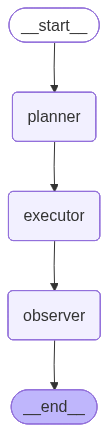

In [3]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## Formal Plan Discovery

The A\* planner discovers `search_web → extract_facts → compose_response`.
Unlike the original LLM plan, this is **verified** to be achievable.

In [ ]:
result = GoapGraph(actions=actions).invoke(
    goal=GoalSpec(conditions={"response_ready": True}),
    world_state={
        "has_task": True,
        "task": "What is the hometown of the 2024 Australian Open winner?",
    },
)

print(f"Status: {result['status']}")
print(f"Response: {result['world_state']['response']}")
print()

# Show the verified action sequence
successful = successful_action_names(result)
print(f"Action sequence: {' → '.join(successful)}")

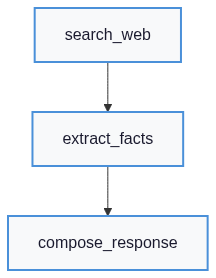

In [5]:
display(Image(result["plan"].draw_mermaid_png()))

## Execution History

Every step produces an `ActionResult` with state snapshots before and after
execution, enabling full traceability.

In [6]:
for entry in result["execution_history"]:
    print(f"  {entry.action_name}: success={entry.success}")
    print(f"    State before keys: {sorted(entry.state_before.keys())}")
    print(f"    State after keys:  {sorted(entry.state_after.keys())}")
    print()

  search_web: success=True
    State before keys: ['has_task', 'task']
    State after keys:  ['has_search_results', 'has_task', 'search_results', 'task']

  extract_facts: success=True
    State before keys: ['has_search_results', 'has_task', 'search_results', 'task']
    State after keys:  ['extracted_text', 'facts', 'has_extracted_facts', 'has_search_results', 'has_task', 'search_results', 'task']

  compose_response: success=True
    State before keys: ['extracted_text', 'facts', 'has_extracted_facts', 'has_search_results', 'has_task', 'search_results', 'task']
    State after keys:  ['extracted_text', 'facts', 'has_extracted_facts', 'has_search_results', 'has_task', 'response', 'response_ready', 'search_results', 'task']



## Replanning on Step Failure

When a step fails (e.g., search API timeout), the observer triggers
replanning from the current state. This replaces the original's LLM
re-prompting with formal replanning.

In [7]:
call_count = {"search": 0}

# Get the real search_web execute from factory-created actions
_real_search = next(a.execute for a in actions if a.name == "search_web")


def flaky_search(ws: dict[str, Any]) -> dict[str, Any]:
    """Fails on first call, succeeds on retry."""
    call_count["search"] += 1
    if call_count["search"] == 1:
        raise RuntimeError("Search API timeout")
    return _real_search(ws)


# Build actions with flaky search swapped in
replan_actions = [
    ActionSpec(
        name=a.name,
        preconditions=dict(a.preconditions),
        effects=dict(a.effects),
        cost=a.cost,
        execute=flaky_search if a.name == "search_web" else a.execute,
    )
    for a in actions
]

result = GoapGraph(actions=replan_actions).invoke(
    goal=GoalSpec(conditions={"response_ready": True}),
    world_state={"has_task": True},
)

print(f"Status: {result['status']}")
print(f"Replans: {result['replan_count']}")
print(f"Search calls: {call_count['search']}")
failures = [h for h in result["execution_history"] if not h.success]
print(f"Failed attempts: {len(failures)}")

Action 'search_web' failed: Search API timeout


Status: goal_achieved
Replans: 1
Search calls: 2
Failed attempts: 1


## NEVER Replan Strategy

With `ReplanStrategy.NEVER`, the system terminates immediately on failure
instead of attempting recovery.

In [8]:
def always_fails(ws: dict[str, Any]) -> dict[str, Any]:
    raise RuntimeError("permanent failure")


# Build actions with always-failing search
never_actions = [
    ActionSpec(
        name=a.name,
        preconditions=dict(a.preconditions),
        effects=dict(a.effects),
        cost=a.cost,
        execute=always_fails if a.name == "search_web" else a.execute,
    )
    for a in actions
]

result = GoapGraph(actions=never_actions).invoke(
    goal=GoalSpec(
        conditions={"response_ready": True},
        replan_strategy=ReplanStrategy.NEVER,
    ),
    world_state={"has_task": True},
)

print(f"Status: {result['status']}")
print(f"Replans: {result['replan_count']}")

Action 'search_web' failed: permanent failure


Status: failed
Replans: 0


## Longer Pipeline: 5-Step Research

The planner handles arbitrarily long pipelines. Here, a 5-step research
pipeline is discovered automatically by A\*.

In [ ]:
result = GoapGraph(actions=five_step_research_actions(llm)).invoke(
    goal=GoalSpec(conditions={"report_complete": True}),
    world_state={"has_task": True, "task": "Research AI planning"},
)

print(f"Status: {result['status']}")
print(f"Report (first 200 chars): {result['world_state']['final_report'][:200]}...")
successful = successful_action_names(result)
print(f"Pipeline: {' -> '.join(successful)}")